# Law of large numbers .....

# As the number of experiments increases, the sample average converges to the true average.

# Demonstration 1: Coin Toss

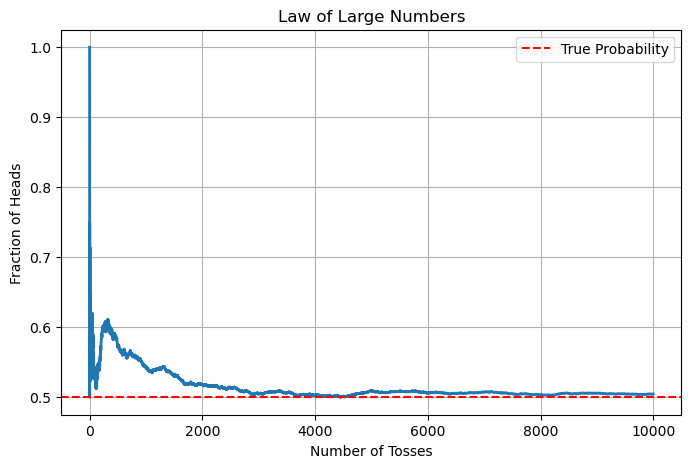

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Law of Large Numbers
# Coin Toss
# -----------------------------

N = 10000

# 1 = Head, 0 = Tail
tosses = np.random.randint(0, 2, N)

running_mean = np.cumsum(tosses) / np.arange(1, N + 1)

plt.figure(figsize=(8,5))

plt.plot(running_mean, linewidth=2)

plt.axhline(0.5,
            color='red',
            linestyle='--',
            label='True Probability')

plt.xlabel("Number of Tosses")
plt.ylabel("Fraction of Heads")
plt.title("Law of Large Numbers")

plt.grid(True)
plt.legend()

plt.show()

# Demonstration 2: Dice

E[X]=3.5

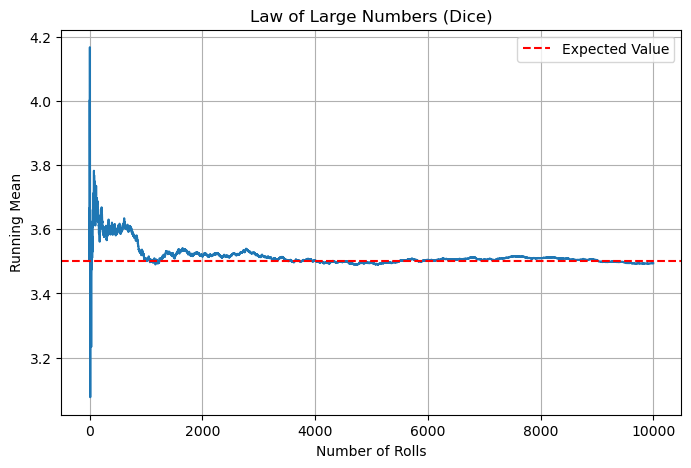

In [2]:
import numpy as np
import matplotlib.pyplot as plt

N = 10000

rolls = np.random.randint(1,7,N)

running_average = np.cumsum(rolls) / np.arange(1,N+1)

plt.figure(figsize=(8,5))

plt.plot(running_average)

plt.axhline(3.5,
            color='red',
            linestyle='--',
            label="Expected Value")

plt.xlabel("Number of Rolls")

plt.ylabel("Running Mean")

plt.title("Law of Large Numbers (Dice)")

plt.grid(True)

plt.legend()

plt.show()

# Demonstration 3: Casino Simulation

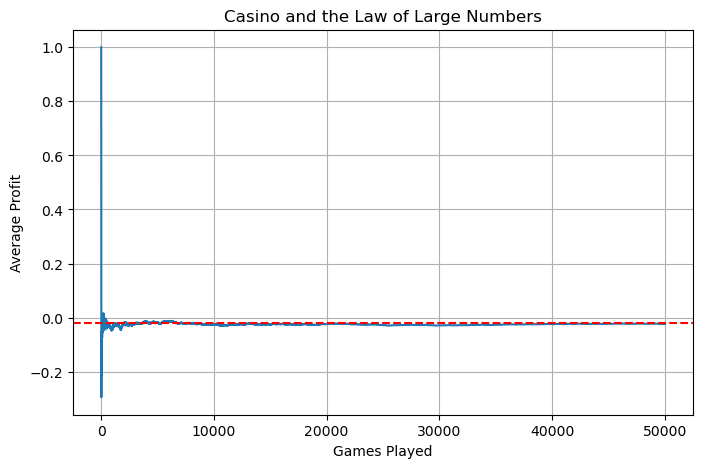

In [3]:
import numpy as np
import matplotlib.pyplot as plt

N = 50000

wins = np.random.choice([1,-1],
                        size=N,
                        p=[0.49,0.51])

average_profit = np.cumsum(wins)/np.arange(1,N+1)

plt.figure(figsize=(8,5))

plt.plot(average_profit)

plt.axhline(-0.02,
            color='red',
            linestyle='--')

plt.xlabel("Games Played")

plt.ylabel("Average Profit")

plt.title("Casino and the Law of Large Numbers")

plt.grid(True)

plt.show()

# Demonstration 4: Rolling Mean of Any Distribution

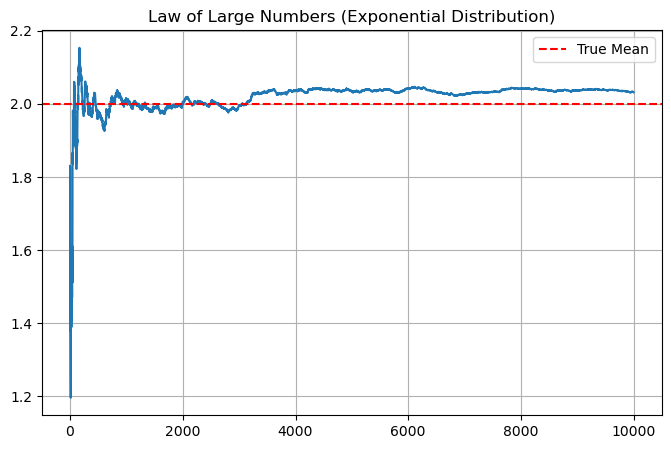

In [4]:
import numpy as np
import matplotlib.pyplot as plt

N = 10000

samples = np.random.exponential(scale=2,size=N)

running_mean = np.cumsum(samples)/np.arange(1,N+1)

plt.figure(figsize=(8,5))

plt.plot(running_mean)

plt.axhline(2,
            color='red',
            linestyle='--',
            label="True Mean")

plt.grid(True)

plt.legend()

plt.title("Law of Large Numbers (Exponential Distribution)")

plt.show()

# Coupon collector 

Simulation Mean : 223.9582
Theory          : 224.96026691647126


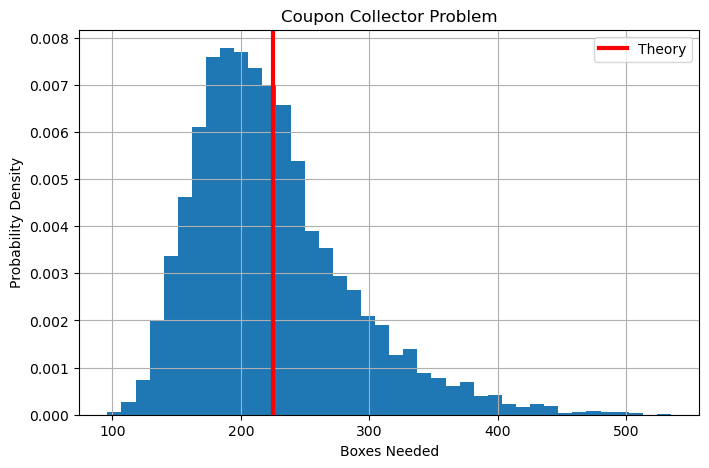

In [5]:
import random
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------
# Coupon Collector Simulation
# ------------------------------------

N = 50               # Number of coupon types
num_trials = 5000

results = []

for _ in range(num_trials):

    collected = set()
    boxes = 0

    while len(collected) < N:

        coupon = random.randint(1, N)

        collected.add(coupon)

        boxes += 1

    results.append(boxes)

results = np.array(results)

# Theory
H = sum(1/i for i in range(1, N+1))
expected = N * H

print("Simulation Mean :", results.mean())
print("Theory          :", expected)

plt.figure(figsize=(8,5))

plt.hist(results,
         bins=40,
         density=True)

plt.axvline(expected,
            color='red',
            linewidth=3,
            label='Theory')

plt.xlabel("Boxes Needed")

plt.ylabel("Probability Density")

plt.title("Coupon Collector Problem")

plt.legend()

plt.grid(True)

plt.show()

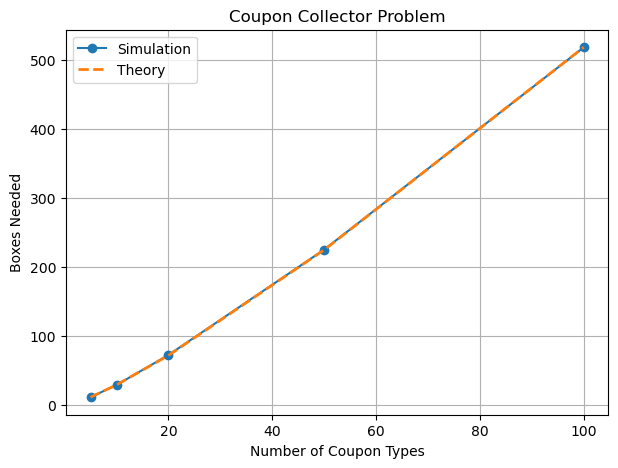

In [6]:
import random
import numpy as np
import matplotlib.pyplot as plt

Ns = [5,10,20,50,100]

simulation = []
theory = []

trials = 1000

for N in Ns:

    values=[]

    for _ in range(trials):

        collected=set()

        count=0

        while len(collected)<N:

            collected.add(random.randint(1,N))

            count+=1

        values.append(count)

    simulation.append(np.mean(values))

    H=sum(1/i for i in range(1,N+1))

    theory.append(N*H)

plt.figure(figsize=(7,5))

plt.plot(Ns,simulation,'o-',label="Simulation")

plt.plot(Ns,theory,'--',linewidth=2,label="Theory")

plt.xlabel("Number of Coupon Types")

plt.ylabel("Boxes Needed")

plt.title("Coupon Collector Problem")

plt.grid(True)

plt.legend()

plt.show()

# Secretary Problem (also called the Marriage Problem or Optimal Stopping Problem)

Best skip fraction = 0.4
Winning probability = 0.3706


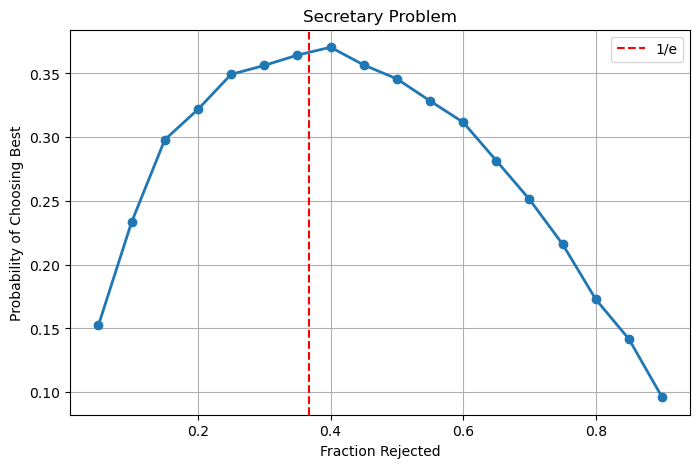

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------
# Secretary Problem Simulation
# --------------------------------------

N = 100
trials = 10000

fractions = np.arange(0.05,0.95,0.05)

probabilities = []

for frac in fractions:

    skip = int(frac*N)

    wins = 0

    for _ in range(trials):

        applicants = np.random.permutation(N)

        best_so_far = np.min(applicants[:skip])

        chosen = None

        for x in applicants[skip:]:

            if x < best_so_far:
                chosen = x
                break

        if chosen is None:
            chosen = applicants[-1]

        if chosen == 0:
            wins += 1

    probabilities.append(wins/trials)

best = np.argmax(probabilities)

print("Best skip fraction =",fractions[best])
print("Winning probability =",probabilities[best])

plt.figure(figsize=(8,5))

plt.plot(fractions,probabilities,'o-',linewidth=2)

plt.axvline(1/np.e,
            color='red',
            linestyle='--',
            label='1/e')

plt.xlabel("Fraction Rejected")

plt.ylabel("Probability of Choosing Best")

plt.title("Secretary Problem")

plt.grid(True)

plt.legend()

plt.show()

# Diesease model

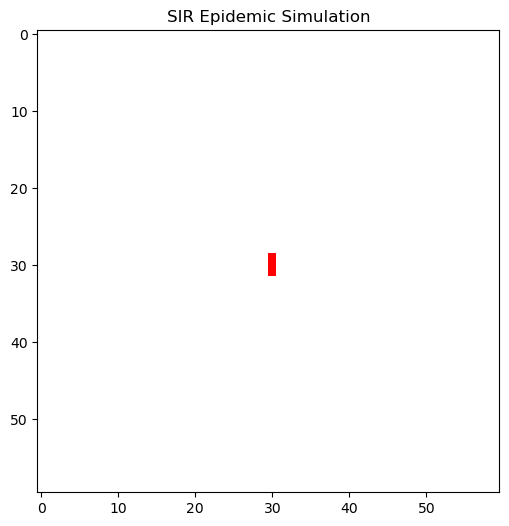

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import ListedColormap

# -------------------------------
# Parameters
# -------------------------------

N = 60                 # Grid size
beta = 0.30            # Infection probability
gamma = 0.05           # Recovery probability
steps = 100

# States
SUSCEPTIBLE = 0
INFECTED = 1
RECOVERED = 2

grid = np.zeros((N, N), dtype=int)

# Initial infected person
grid[N//2, N//2] = INFECTED

cmap = ListedColormap(["white", "red", "blue"])

fig, ax = plt.subplots(figsize=(6,6))
im = ax.imshow(grid, cmap=cmap, vmin=0, vmax=2)

ax.set_title("SIR Epidemic Simulation")

# -----------------------------------

def update(frame):

    global grid

    new_grid = grid.copy()

    for i in range(N):
        for j in range(N):

            if grid[i,j] == INFECTED:

                # Try to infect neighbors
                for di,dj in [(-1,0),(1,0),(0,-1),(0,1)]:

                    ni = i + di
                    nj = j + dj

                    if 0 <= ni < N and 0 <= nj < N:

                        if grid[ni,nj] == SUSCEPTIBLE:

                            if np.random.rand() < beta:
                                new_grid[ni,nj] = INFECTED

                # Recovery
                if np.random.rand() < gamma:
                    new_grid[i,j] = RECOVERED

    grid = new_grid

    im.set_array(grid)

    return [im]

ani = FuncAnimation(fig,
                    update,
                    frames=steps,
                    interval=100,
                    blit=True)

plt.show()

In [12]:
S = np.sum(grid == SUSCEPTIBLE)
I = np.sum(grid == INFECTED)
R = np.sum(grid == RECOVERED)

In [13]:
print(S,I,R)

3597 3 0


# Bayesian Disease Testing

Suppose:

- Disease prevalence = **1%**
- Test sensitivity = **99%**
- Test specificity = **95%**

A person tests **positive**.

## Question

> **What is the probability that the person actually has the disease?**

Most people intuitively answer **95%** or **99%**, but the correct answer is much lower.

---

## Bayes' Theorem

Let

- \(D\): Person has the disease.
- \(+\): Test result is positive.

Then,

$$
P(D\mid +)=
\frac{P(+\mid D)P(D)}
{P(+)}
$$

where

$$
P(+)=
P(+\mid D)P(D)
+
P(+\mid \overline{D})P(\overline{D}).
$$

---

## Given Data

Disease prevalence:

$$
P(D)=0.01
$$

Therefore,

$$
P(\overline{D})=0.99
$$

Sensitivity (True Positive Rate):

$$
P(+\mid D)=0.99
$$

Specificity:

$$
P(-\mid \overline{D})=0.95
$$

Hence the False Positive Rate is

$$
P(+\mid \overline{D})=1-0.95=0.05.
$$

---

## Compute the Probability of a Positive Test

$$
\begin{aligned}
P(+)
&=
P(+\mid D)P(D)
+
P(+\mid \overline{D})P(\overline{D})\\
&=
(0.99)(0.01)
+
(0.05)(0.99)\\
&=
0.0099+0.0495\\
&=
0.0594.
\end{aligned}
$$

---

## Apply Bayes' Theorem

$$
\begin{aligned}
P(D\mid +)
&=
\frac{P(+\mid D)P(D)}
{P(+)}\\
&=
\frac{0.99\times0.01}
{0.0594}\\
&=
\frac{0.0099}{0.0594}\\
&\approx0.1667.
\end{aligned}
$$

Therefore,

$$
\boxed{
P(D\mid +)\approx16.7\%
}
$$

---

## Interpretation

Imagine **10,000 people** are tested.

- **100** actually have the disease.
- **9,900** are healthy.

Among the **100 diseased**:

- 99 test positive.
- 1 tests negative.

Among the **9,900 healthy**:

- 495 test positive (false positives).
- 9,405 test negative.

Therefore,

$$
\text{Total Positive Tests}
=
99+495
=
594.
$$

Thus,

$$
P(D\mid +)
=
\frac{99}{594}
\approx0.1667.
$$

Hence,

> **Only about 1 in every 6 positive tests is a true positive**, despite the test having **99% sensitivity** and **95% specificity**.

This illustrates the importance of **base rates (disease prevalence)** when interpreting medical test results.

In [15]:
import numpy as np

# -----------------------------
# Parameters
# -----------------------------

population = 1_000_000

prevalence = 0.01      # 1%

sensitivity = 0.99     # True positive rate

specificity = 0.95     # True negative rate

# -----------------------------
# Simulate population
# -----------------------------

disease = np.random.rand(population) < prevalence

positive = np.zeros(population, dtype=bool)

# Diseased people
positive[disease] = np.random.rand(np.sum(disease)) < sensitivity

# Healthy people
positive[~disease] = np.random.rand(np.sum(~disease)) < (1-specificity)

# -----------------------------
# Compute probability
# -----------------------------

posterior = np.sum(disease & positive) / np.sum(positive)

print("Probability of disease given positive test:")
print(posterior)

Probability of disease given positive test:
0.1658283823926546
